In [1]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9

#two ground stations
#gs1_0 = generate_point(R, (10)*np.pi/180, 1*np.pi/180) # NY 40.7128° N, 74.0060° W
gs1_0 = generate_point(R, (90-40.7128)*np.pi/180, 74.0060*np.pi/180) # NY 40.7128° N, 74.0060° W
gs2_0 = generate_point(R, (90-33.7490)*np.pi/180, 84.3880*np.pi/180) # ATL 33.7490° N, 84.3880° W
gs3_0 = generate_point(R, (90-34.0522)*np.pi/180, 118.2437*np.pi/180) # LA 34.0522° N, 118.2437° W
gs4_0 = generate_point(R, (90-47.6062)*np.pi/180, 122.3321*np.pi/180) # SEA 47.6062° N, 122.3321° W

axis_earth = np.array([0,0,1]) #z-axis

#satellite
sat_0 = generate_point(R+h, 90*np.pi/180, 0*np.pi/180)
theta = 90;
axis_sat = np.array([0, math.sin(theta*np.pi/180), math.cos(theta*np.pi/180)]) # tilted axis in y-z plane

T_big = 86400
dT = 1
bigsteps = math.floor(T_big/dT)

# pc_up1 = np.array([]); pc_up2 = np.array([]); pc_up3 = np.array([]); pc_up4 = np.array([])
# angles1 = np.array([]); angles2 = np.array([]); angles3 = np.array([]); angles4 = np.array([]);
# distances1 = np.array([]); distances2 = np.array([]); distances3 = np.array([]); distances4 = np.array([]);

def sat_dynamics(t):
    
    #for t_gb in range(bigsteps):
    t_gb = t

    if t_gb%10000 == 0:
        print(t_gb)

    gs1 = evolve_vector(gs1_0, axis_earth, Om, t_gb*dT)
    gs2 = evolve_vector(gs2_0, axis_earth, Om, t_gb*dT)
    gs3 = evolve_vector(gs3_0, axis_earth, Om, t_gb*dT)
    gs4 = evolve_vector(gs4_0, axis_earth, Om, t_gb*dT)

    sat = evolve_vector(sat_0, axis_sat, om, t_gb*dT)

    angs =[np.dot(np.subtract(sat,gs1),gs1)/np.linalg.norm(gs1)/np.linalg.norm(np.subtract(sat,gs1)), 
        np.dot(np.subtract(sat,gs2),gs2)/np.linalg.norm(gs2)/np.linalg.norm(np.subtract(sat,gs2)),
              np.dot(np.subtract(sat,gs3),gs3)/np.linalg.norm(gs3)/np.linalg.norm(np.subtract(sat,gs3)),
            np.dot(np.subtract(sat,gs4),gs4)/np.linalg.norm(gs4)/np.linalg.norm(np.subtract(sat,gs4))]

    dists = [dst(gs1, sat), dst(gs2, sat), dst(gs3, sat), dst(gs4, sat)]


    eff_gs1_sat = eta(dists[0], h, 0.6, 0.1, 0.25)
    eff_gs2_sat = eta(dists[1], h, 0.6, 0.1, 0.25)
    eff_gs3_sat = eta(dists[2], h, 0.6, 0.1, 0.25)
    eff_gs4_sat = eta(dists[3], h, 0.6, 0.1, 0.25)

    #gs velocities
    v_gs1 = np.cross(gs1, Om*axis_earth)
    v_gs2 = np.cross(gs2, Om*axis_earth)
    v_gs3 = np.cross(gs3, Om*axis_earth)
    v_gs4 = np.cross(gs4, Om*axis_earth)

    #satellite velocity
    v_sat = np.cross(sat, om*axis_sat)

    #radial relative velocities
    v_rel_radial1 = np.dot(np.subtract(v_sat, v_gs1), np.subtract(sat, gs1)/np.linalg.norm(np.subtract(sat, gs1)))
    v_rel_radial2 = np.dot(np.subtract(v_sat, v_gs2), np.subtract(sat, gs2)/np.linalg.norm(np.subtract(sat, gs2)))
    v_rel_radial3 = np.dot(np.subtract(v_sat, v_gs3), np.subtract(sat, gs3)/np.linalg.norm(np.subtract(sat, gs3)))
    v_rel_radial4 = np.dot(np.subtract(v_sat, v_gs4), np.subtract(sat, gs4)/np.linalg.norm(np.subtract(sat, gs4)))

    #t_shift = t_bin/v_rel

    T1 = dt/abs(v_rel_radial1/c)
    T2 = dt/abs(v_rel_radial2/c)
    T3 = dt/abs(v_rel_radial3/c)
    T4 = dt/abs(v_rel_radial4/c)

    K1 = abs(v_rel_radial1/c)#1/abs(v_rel_radial1/c)
    eta_up1 = eff_gs1_sat
    
    pc_ups = [(eff_gs1_sat*pair_rate*T1), (eff_gs2_sat*pair_rate*T2), (eff_gs3_sat*pair_rate*T3),
               (eff_gs4_sat*pair_rate*T4)]
        
    return(pc_ups[0],pc_ups[1],pc_ups[2],pc_ups[3], angs[0], angs[1], angs[2], angs[3], K1, eta_up1, dists[0])

t_start = time.time()
data = Parallel(n_jobs=15)(delayed(sat_dynamics)(t) for t in range(bigsteps))
print(time.time() - t_start)


print("game over")        
np.save('data_4cities_1sat_notilt.npy', data)

207.96238803863525
game over


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
T_big = 86400
dT = 1
dt = 1e-9
bigsteps = math.floor(T_big/dT)
N_c = 10

data = np.load('data_4cities_1sat_notilt.npy', allow_pickle=True)
pc_up1 = np.array([]); pc_up2 = np.array([]); pc_up3 = np.array([]); pc_up4 = np.array([])
angles1 = np.array([]); angles2 = np.array([]); angles3 = np.array([]); angles4 = np.array([]);


pc_up1 = [data[i][0] for i in range(bigsteps)]
pc_up2 = [data[i][1] for i in range(bigsteps)]
pc_up3 = [data[i][2] for i in range(bigsteps)]
pc_up4 = [data[i][3] for i in range(bigsteps)]

angles1 = [data[i][4] for i in range(bigsteps)]
angles2 = [data[i][5] for i in range(bigsteps)]
angles3 = [data[i][6] for i in range(bigsteps)]
angles4 = [data[i][7] for i in range(bigsteps)]

K1 = [data[i][8] for i in range(bigsteps)]
eta_up1 = [data[i][9] for i in range(bigsteps)]
dist1 = [data[i][10] for i in range(bigsteps)]


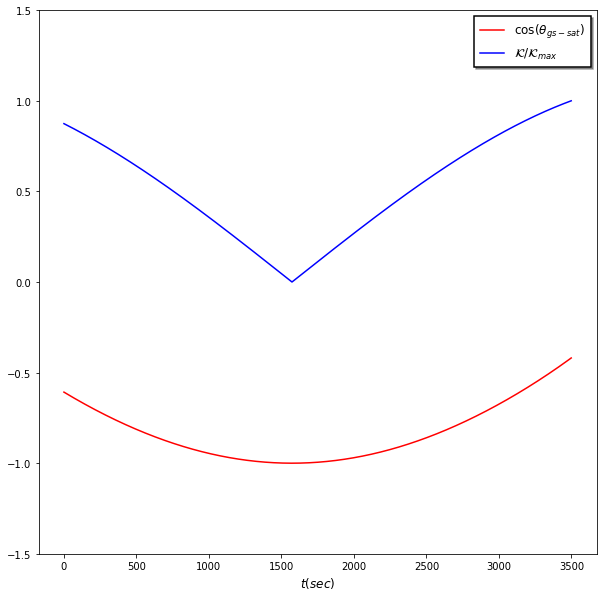

In [4]:
#1-2
c_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, pc_up1[i])
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlabel(r'$t (sec)$', fontsize=12)
ax.set_ylim(-1.5,1.5)
#ax.set_ylabel(r'$-log_{10}(t_{bin}) $', fontsize=12)
ax.plot([i for i in range(bigsteps)], angles1, color='r')
ax.plot([i for i in range(bigsteps)], K1/np.max(K1), color='b')

#legend format
leg = ax.legend(((r'$\cos(\theta_{gs-sat})$', r'$\mathcal{K}/\mathcal{K}_{max}$')), fontsize=12, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)



# plt.savefig("angles_and_kappa_vs_time_NYC.pdf" , dpi=600, facecolor='w', edgecolor='w',
#         orientation='landscape', format='pdf',
#         transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide


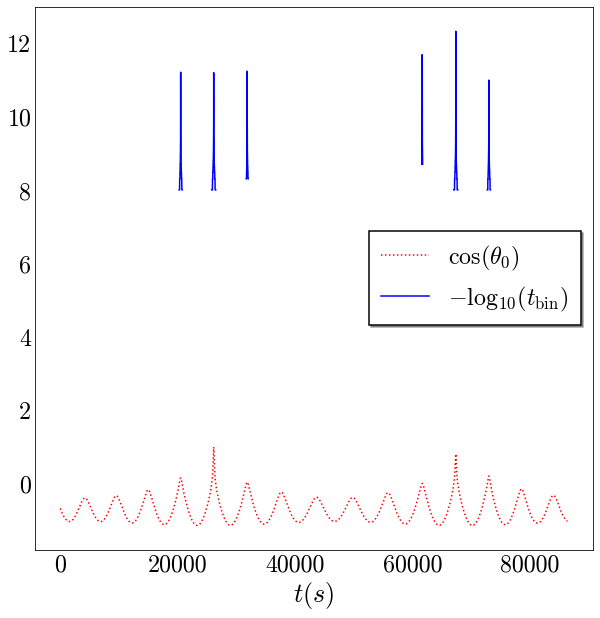

In [5]:
#1-2
import matplotlib.pyplot as plt
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rc('axes', unicode_minus=False)
c_success = np.array([0]*bigsteps)
t_success = np.array([0]*bigsteps)

for i in range(bigsteps):
    
    if angles1[i]>1e-10:
        t_success[i] = i*dT
        c_success[i] = pc_up1[i]
    else:
        c_success[i] = 0


'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlabel(r'$t (s)$', fontsize=26)

ax.plot([i for i in range(bigsteps)], angles1/np.max(angles1), color='r', linestyle='dotted')
ax.plot([i*dT for i in range(bigsteps)], -np.log10(dt*N_c/c_success), color='b')


plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)
# legend format
leg = ax.legend(((r'$\cos(\theta_0)$', r'$-\log_{10}(t_{\rm bin})$')), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='center right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("angles_and_precision_vs_time_NYC.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

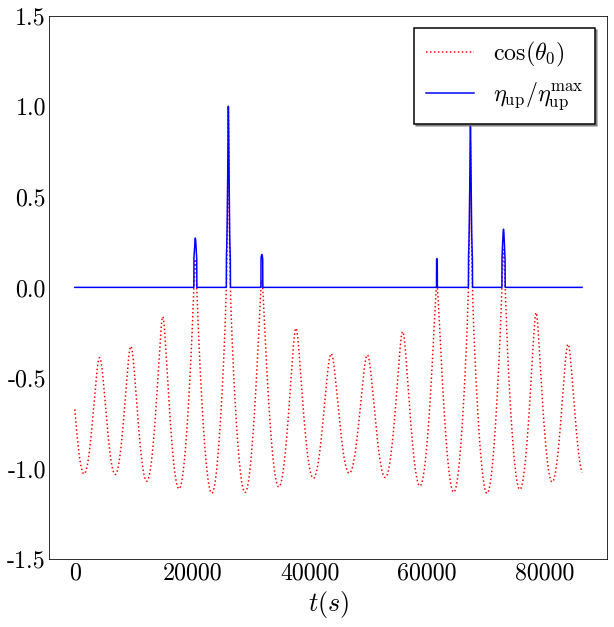

In [6]:
#1-2
import matplotlib.pyplot as plt
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rc('axes', unicode_minus=False)

eta_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10:
        t_success = np.append(t_success, i)
        eta_success = np.append(eta_success, eta_up1[i])
    else:
        eta_success = np.append(eta_success, 0)
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlabel(r'$t (s)$', fontsize=26)
ax.set_ylim(-1.5,1.5)
#ax.set_ylabel(r'$-log_{10}(t_{bin}) $', fontsize=12)
ax.plot([i for i in range(bigsteps)], angles1/np.max(angles1), color='r', linestyle='dotted')
ax.plot([i for i in range(bigsteps)], eta_success/np.max(eta_success), color='b')

leg.get_frame().set_linewidth(1.5)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)


#legend format
leg = ax.legend(((r'$\cos(\theta_0)$', r'$\eta_{\rm up}/\eta_{\rm up}^{\rm max}$')), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)



plt.savefig("angles_and_uplink_loss_vs_time_NYC.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

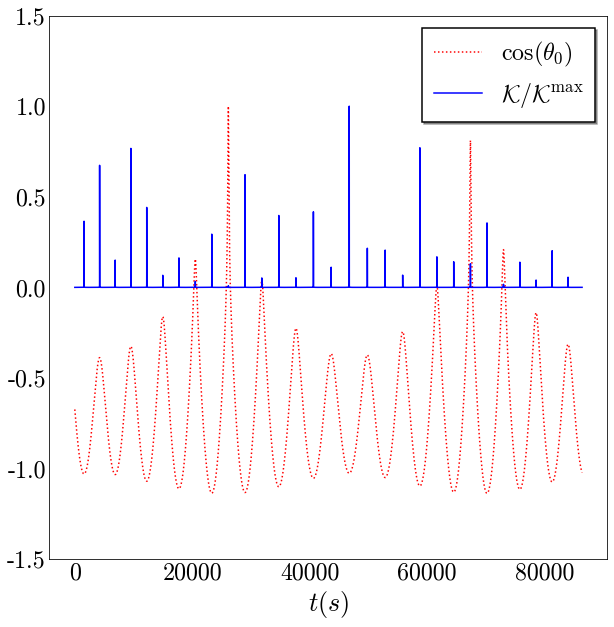

In [7]:
#1-2
import matplotlib.pyplot as plt
plt.rc('font', family='serif', serif='cmr10')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rc('axes', unicode_minus=False)


'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlabel(r'$t (s)$', fontsize=26)
ax.set_ylim(-1.5,1.5)
K1 = np.array(K1)
#ax.set_ylabel(r'$-log_{10}(t_{bin}) $', fontsize=12)
ax.plot([i for i in range(bigsteps)], angles1/np.max(angles1), color='r', linestyle='dotted')
ax.plot([i for i in range(bigsteps)], (1/K1)/np.max(1/K1), color='b')

leg.get_frame().set_linewidth(1.5)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)


#legend format
leg = ax.legend(((r'$\cos(\theta_0)$', r'$\mathcal{K}/\mathcal{K}^{\rm max}$')), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
# bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)



plt.savefig("angles_and_kappa_vs_time_NYC.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

[0. 0. 0. ... 0. 0. 9.]
[0. 0. 0. ... 0. 9. 9.]


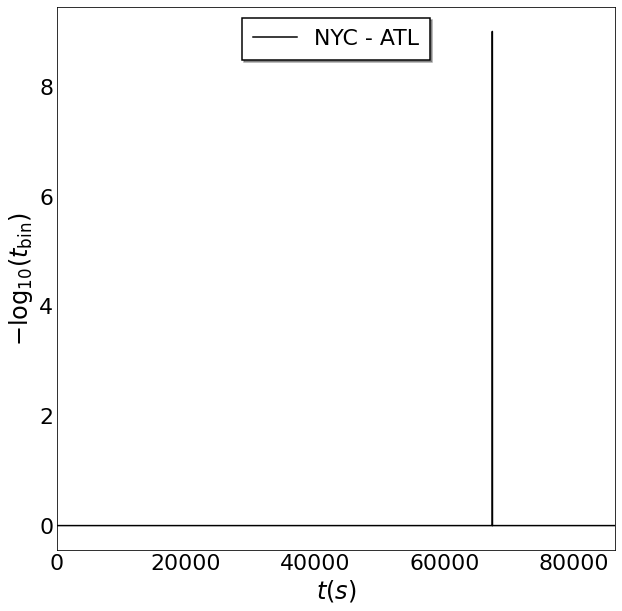

In [2]:
#1-2
c_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10 and angles2[i]>1e-10 and pc_up1[i]>N_c and pc_up2[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, -np.log10(dt*N_c/min(pc_up1[i], pc_up2[i], N_c)))
        print(c_success)
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
# ax.set_ylim(0,10)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=22)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=22)

leg = ax.legend((('NYC - ATL', )), fontsize=22, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_ATL_simul.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

In [ ]:
#1-2
c_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10 and angles2[i]>1e-10 and pc_up1[i]>N_c and pc_up2[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, -np.log10(dt*N_c/min(pc_up1[i], pc_up2[i], N_c)))
        print(c_success)
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
# ax.set_ylim(0,10)

plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

leg = ax.legend((('NYC - ATL', )), fontsize=18, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_ATL_simul.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

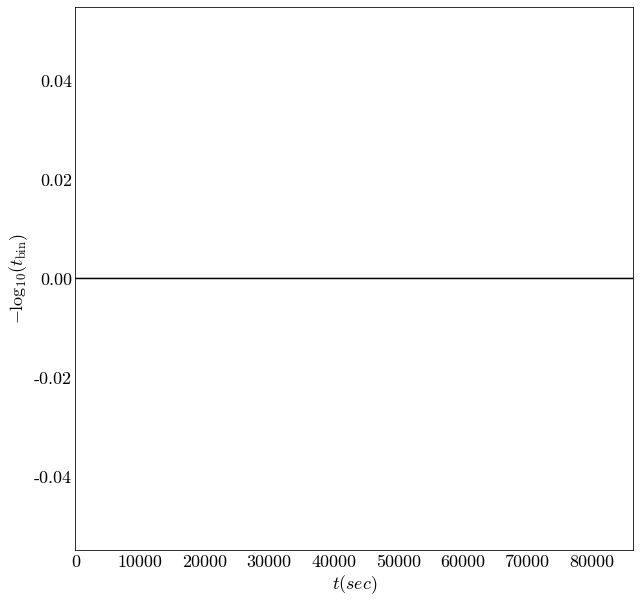

In [23]:
#1-3
c_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10 and angles3[i]>1e-10 and pc_up1[i]>N_c and pc_up3[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, min(pc_up1[i], pc_up3[i]))
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)

plt.savefig("precision_NYC_LA_simul.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

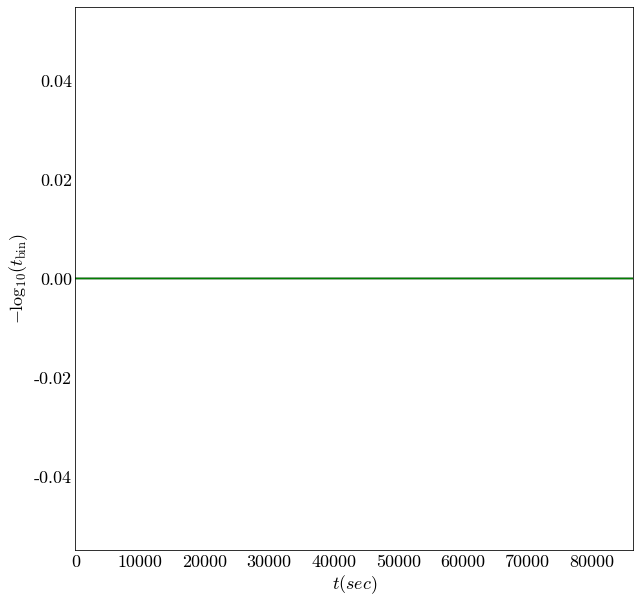

In [24]:
#1-4
c_success = np.array([])
t_success = np.array([])

for i in range(bigsteps):
        
    if angles1[i]>1e-10 and angles4[i]>1e-10 and pc_up1[i]>N_c and pc_up4[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, min(pc_up1[i], pc_up4[i]))
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'g')  

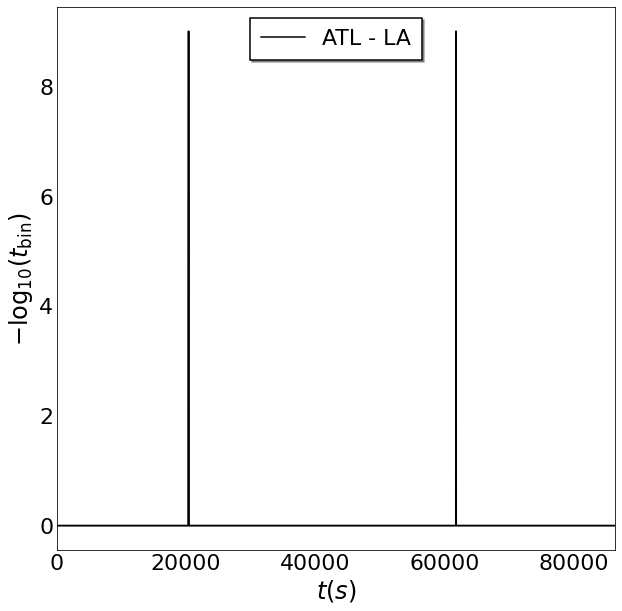

In [3]:
#2-3
c_success = np.array([])
t_success = np.array([])
N_c = 10

for i in range(bigsteps):
        
    if angles2[i]>1e-10 and angles3[i]>1e-10 and pc_up2[i]>N_c and pc_up3[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, -np.log10(dt*N_c/min(pc_up2[i], pc_up3[i], N_c)))
    else:
        c_success = np.append(c_success, 0)
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=22)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=22)

leg = ax.legend((('ATL - LA', )), fontsize=22, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   

plt.savefig("precision_ATL_LA_simul.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

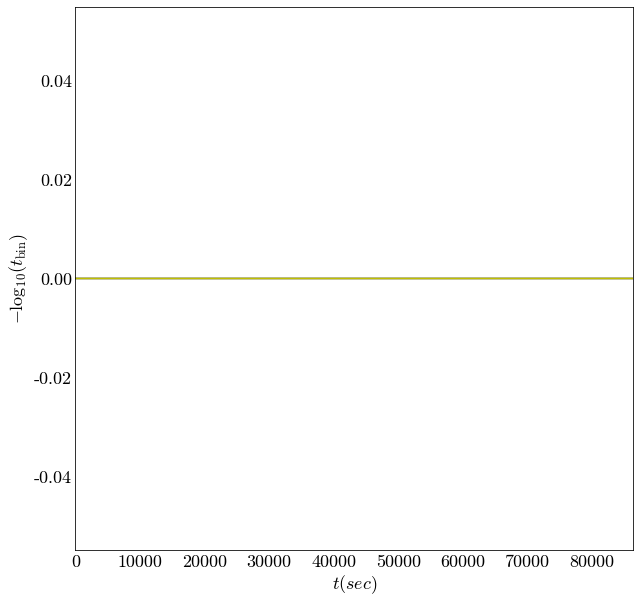

In [26]:
#2-4
c_success = np.array([])
t_success = np.array([])
N_c = 10

for i in range(bigsteps):
        
    if angles2[i]>1e-10 and angles4[i]>1e-10 and pc_up2[i]>N_c and pc_up4[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, min(pc_up2[i], pc_up4[i]))
    else:
        c_success = np.append(c_success, 0)

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'y')

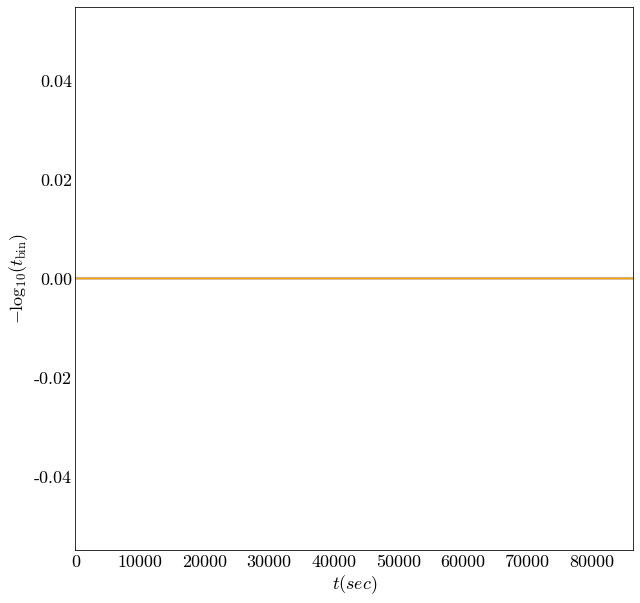

In [27]:
#3-4
c_success = np.array([])
t_success = np.array([])
N_c = 10

for i in range(bigsteps):
        
    if angles3[i]>1e-10 and angles4[i]>1e-10 and pc_up3[i]>N_c and pc_up4[i]>N_c:
        t_success = np.append(t_success, i)
        c_success = np.append(c_success, min(pc_up3[i], pc_up4[i]))
    else:
        c_success = np.append(c_success, 0)
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'black')   
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=18)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=18)
ax.plot([i for i in range(bigsteps)], c_success, color = 'orange')

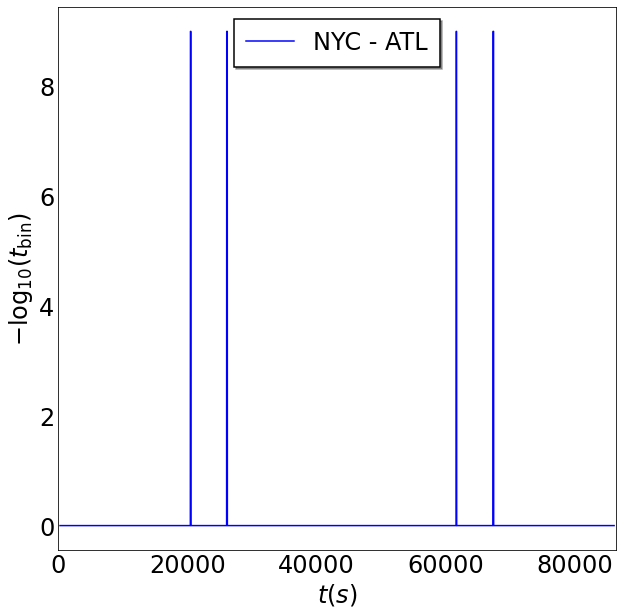

In [2]:
#1-2
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        for j in range(tau):
            
            if (angles2[i+j]>1e-10 and pc_up2[i+j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up2[i+j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up2[i+j], N_c)
                    
            if (angles2[i-j]>1e-10 and pc_up2[i-j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up2[i-j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up2[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
        

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('NYC - ATL', )), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_ATL_10mins_new.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

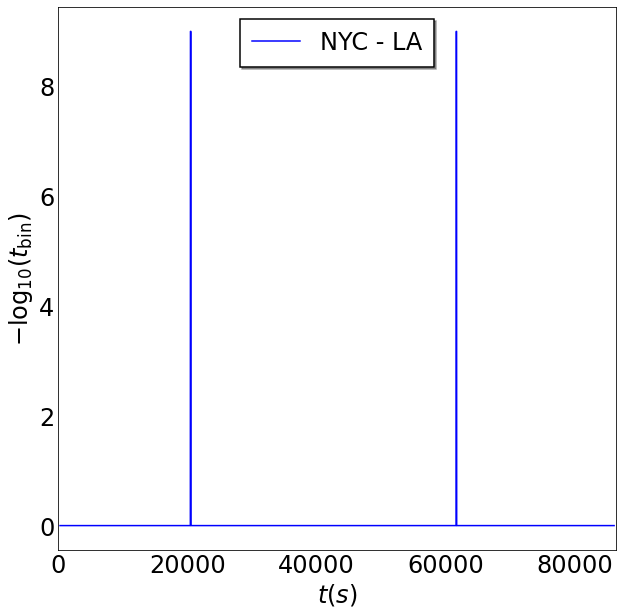

In [3]:
#1-3
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        for j in range(tau):
            if (angles3[i+j]>1e-10 and pc_up3[i+j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up3[i+j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up3[i+j], N_c)
                    
            if (angles3[i-j]>1e-10 and pc_up3[i-j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up3[i-j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up3[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('NYC - LA', )), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_LA_10mins_new.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

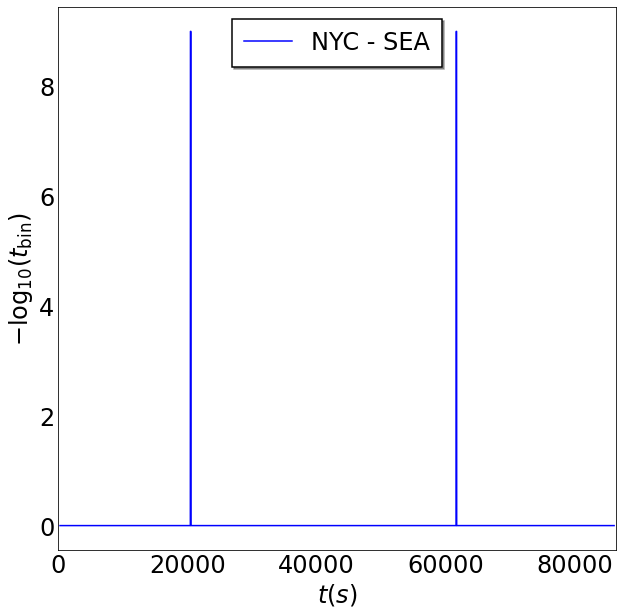

In [4]:
#1-4
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        for j in range(tau):
            if (angles4[i+j]>1e-10 and pc_up4[i+j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up4[i+j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up4[i+j], N_c)
                    
            if (angles4[i-j]>1e-10 and pc_up4[i-j]>N_c):
                flag = 1
                if min(pc_up1[i], pc_up4[i-j], N_c)>c_temp:
                    c_temp = min(pc_up1[i], pc_up4[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)
ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('NYC - SEA', )), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_SEA_5mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

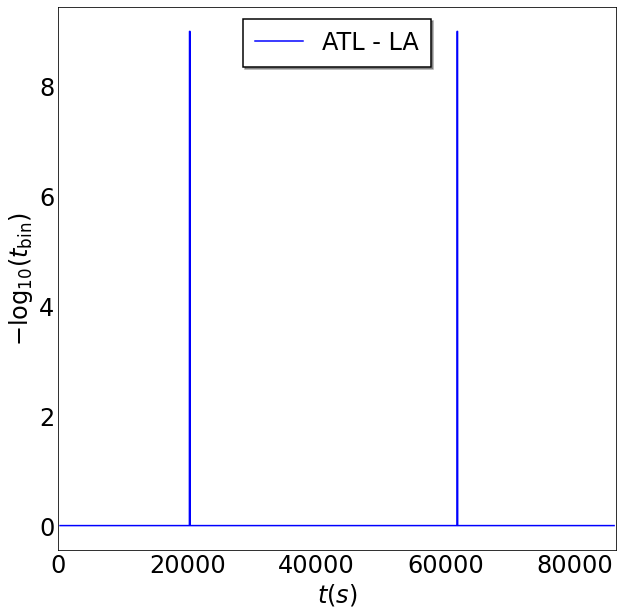

In [5]:
#2-3
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles2[i]>1e-10 and pc_up2[i]>N_c:
        for j in range(tau):
            if (angles3[i+j]>1e-10 and pc_up3[i+j]>N_c):
                flag = 1
                if min(pc_up2[i], pc_up3[i+j], N_c)>c_temp:
                    c_temp = min(pc_up2[i], pc_up3[i+j], N_c)
                    
            if (angles3[i-j]>1e-10 and pc_up3[i-j]>N_c):
                flag = 1
                if min(pc_up2[i], pc_up3[i-j], N_c)>c_temp:
                    c_temp = min(pc_up2[i], pc_up3[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
    
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)
ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('ATL - LA', )), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_ATL_LA_5mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

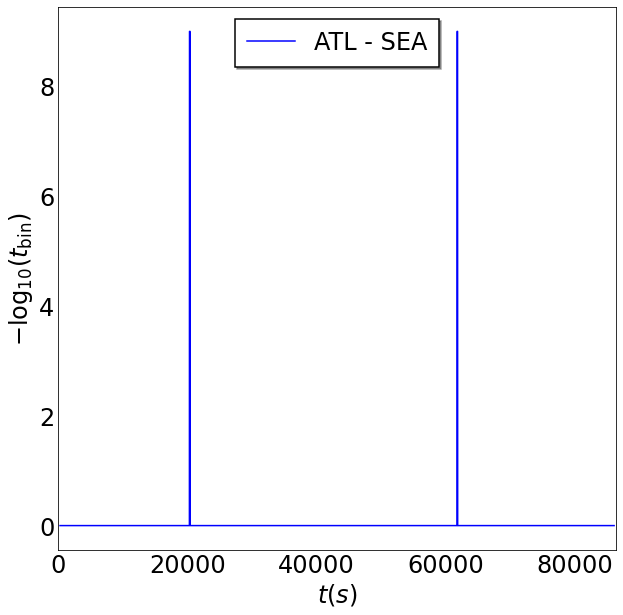

In [6]:
#2-4
c_success = np.array([])
t_success = np.array([])


N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles2[i]>1e-10 and pc_up2[i]>N_c:
        for j in range(tau):
            if (angles4[i+j]>1e-10 and pc_up4[i+j]>N_c):
                flag = 1
                if min(pc_up2[i], pc_up4[i+j], N_c)>c_temp:
                    c_temp = min(pc_up2[i], pc_up4[i+j], N_c)
                    
            if (angles4[i-j]>1e-10 and pc_up4[i-j]>N_c):
                flag = 1
                if min(pc_up2[i], pc_up4[i-j], N_c)>c_temp:
                    c_temp = min(pc_up2[i], pc_up4[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
    
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('ATL - SEA', )), fontsize=24, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_ATL_SEA_5mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

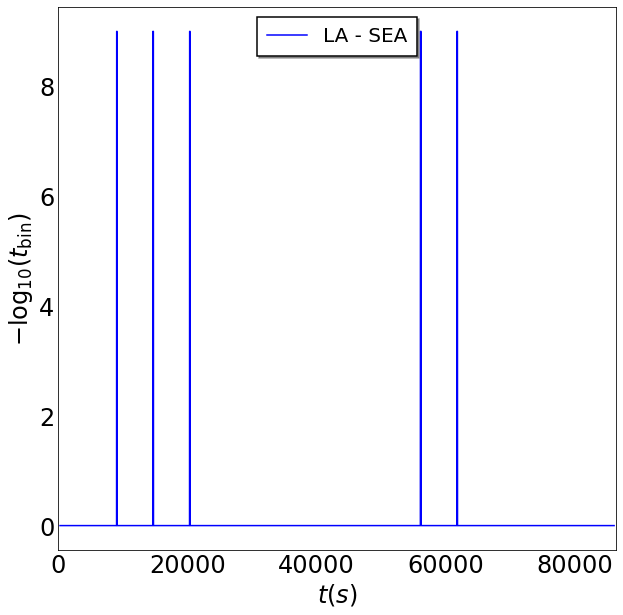

In [10]:
#3-4
c_success = np.array([])
t_success = np.array([])


N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles3[i]>1e-10 and pc_up3[i]>N_c:
        for j in range(tau):
            if (angles4[i+j]>1e-10 and pc_up4[i+j]>N_c):
                flag = 1
                if min(pc_up3[i], pc_up4[i+j], N_c)>c_temp:
                    c_temp = min(pc_up3[i], pc_up4[i+j], N_c)
                    
            if (angles4[i-j]>1e-10 and pc_up4[i-j]>N_c):
                flag = 1
                if min(pc_up3[i], pc_up4[i-j], N_c)>c_temp:
                    c_temp = min(pc_up3[i], pc_up4[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
    
        
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (s)$', fontsize=24)
ax.set_ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=24)
 
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=24)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=24)
ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('LA - SEA', )), fontsize=20, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper center')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_LA_SEA_10mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


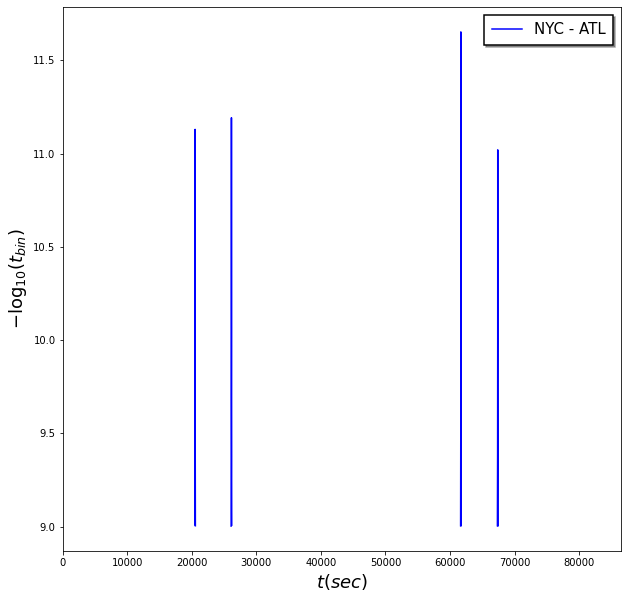

In [6]:
#1-2
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 150


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles2[i+j]>1e-10 and pc_up2[i+j]>N_c:
                
                if min(pc_up1[i], pc_up2[i+j])>max_count:
                    max_count = min(pc_up1[i], pc_up2[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles2[i-j]>1e-10 and pc_up2[i-j]>N_c:
                    if min(pc_up1[i], pc_up2[i-j])>max_count:
                        max_count = min(pc_up1[i], pc_up2[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=18)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=18)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'b') 

#legend format
leg = ax.legend((('NYC - ATL', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_NYC_ATL_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


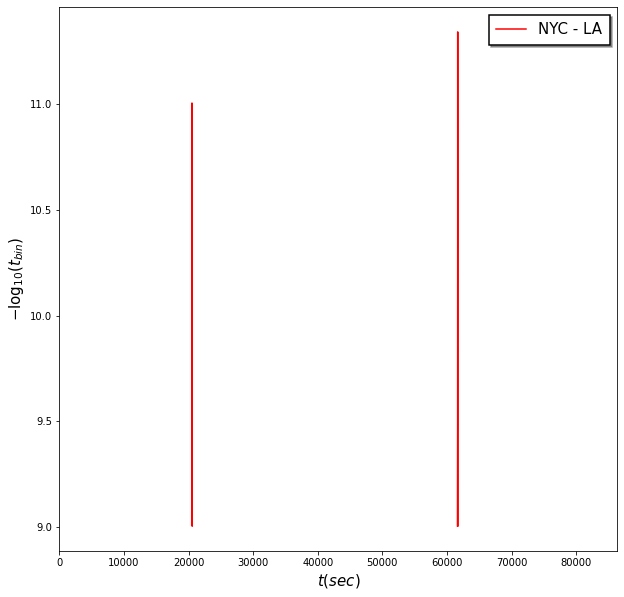

In [7]:
#1-3
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 180


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles3[i+j]>1e-10 and pc_up3[i+j]>N_c:
                
                if min(pc_up1[i], pc_up3[i+j])>max_count:
                    max_count = min(pc_up1[i], pc_up3[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles3[i-j]>1e-10 and pc_up3[i-j]>N_c:
                    if min(pc_up1[i], pc_up3[i-j])>max_count:
                        max_count = min(pc_up1[i], pc_up3[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'r') 

#legend format
leg = ax.legend((('NYC - LA', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)



plt.savefig("precision_NYC_LA_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


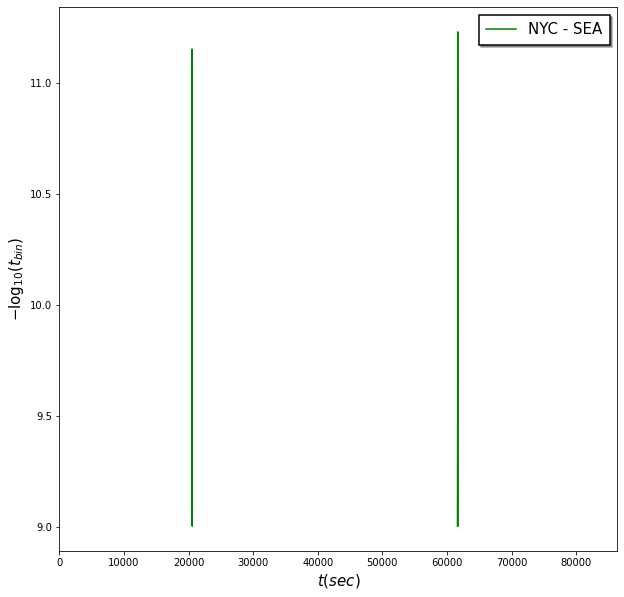

In [8]:
#1-4
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 180


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles1[i]>1e-10 and pc_up1[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles4[i+j]>1e-10 and pc_up4[i+j]>N_c:
                
                if min(pc_up1[i], pc_up4[i+j])>max_count:
                    max_count = min(pc_up1[i], pc_up4[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles4[i-j]>1e-10 and pc_up4[i-j]>N_c:
                    if min(pc_up1[i], pc_up4[i-j])>max_count:
                        max_count = min(pc_up1[i], pc_up4[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'g') 

#legend format
leg = ax.legend((('NYC - SEA', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)


plt.savefig("precision_NYC_SEA_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


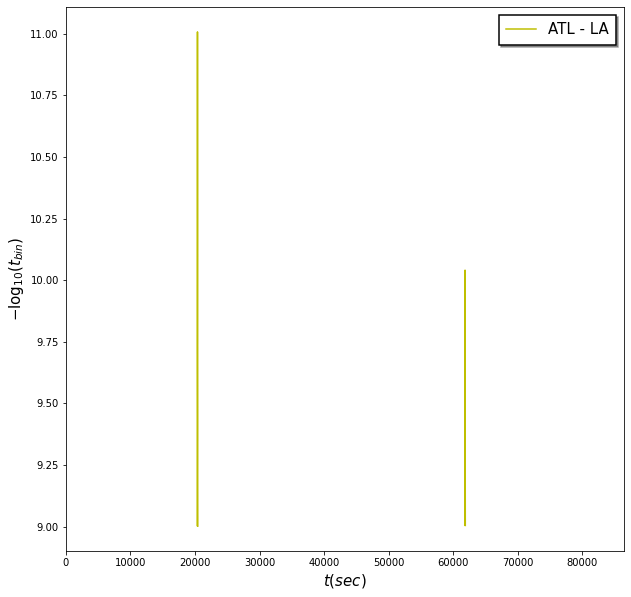

In [9]:
#2-3
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 180


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles2[i]>1e-10 and pc_up2[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles3[i+j]>1e-10 and pc_up3[i+j]>N_c:
                
                if min(pc_up2[i], pc_up3[i+j])>max_count:
                    max_count = min(pc_up2[i], pc_up3[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles3[i-j]>1e-10 and pc_up3[i-j]>N_c:
                    if min(pc_up2[i], pc_up3[i-j])>max_count:
                        max_count = min(pc_up2[i], pc_up3[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'y') 

#legend format
leg = ax.legend((('ATL - LA', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)


plt.savefig("precision_ATL_LA_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


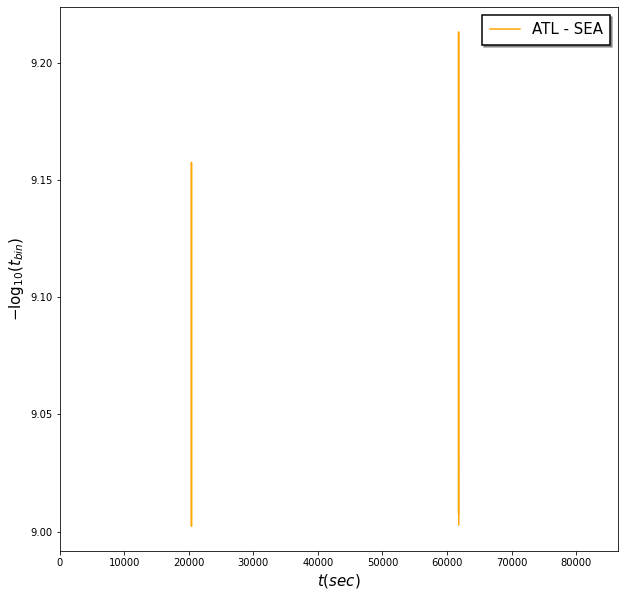

In [12]:
#2-4
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 180


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles2[i]>1e-10 and pc_up2[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles4[i+j]>1e-10 and pc_up4[i+j]>N_c:
                
                if min(pc_up2[i], pc_up4[i+j])>max_count:
                    max_count = min(pc_up2[i], pc_up4[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles4[i-j]>1e-10 and pc_up4[i-j]>N_c:
                    if min(pc_up2[i], pc_up4[i-j])>max_count:
                        max_count = min(pc_up2[i], pc_up4[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'orange') 

#legend format
leg = ax.legend((('ATL - SEA', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)


plt.savefig("precision_ATL_SEA_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


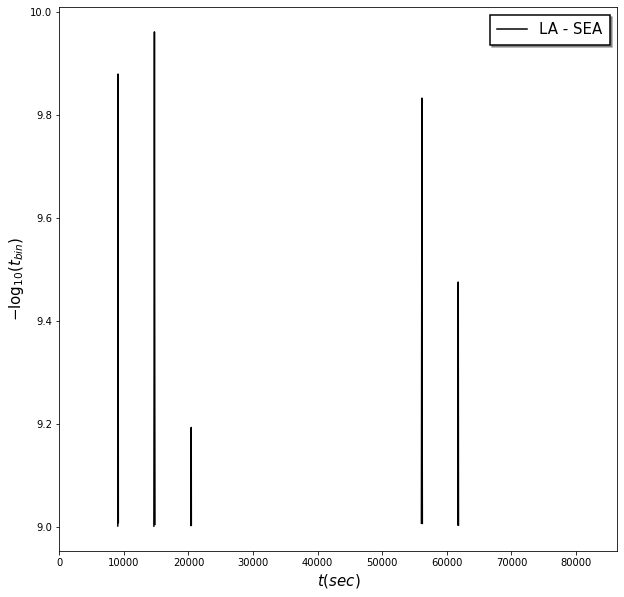

In [11]:
#3-4
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 180


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles3[i]>1e-10 and pc_up3[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles4[i+j]>1e-10 and pc_up4[i+j]>N_c:
                
                if min(pc_up3[i], pc_up4[i+j])>max_count:
                    max_count = min(pc_up3[i], pc_up4[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles4[i-j]>1e-10 and pc_up4[i-j]>N_c:
                    if min(pc_up3[i], pc_up4[i-j])>max_count:
                        max_count = min(pc_up3[i], pc_up4[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'black') 

#legend format
leg = ax.legend((('LA - SEA', )), fontsize=15, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)


plt.savefig("precision_LA_SEA_3mins.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

/home/hstav/.local/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


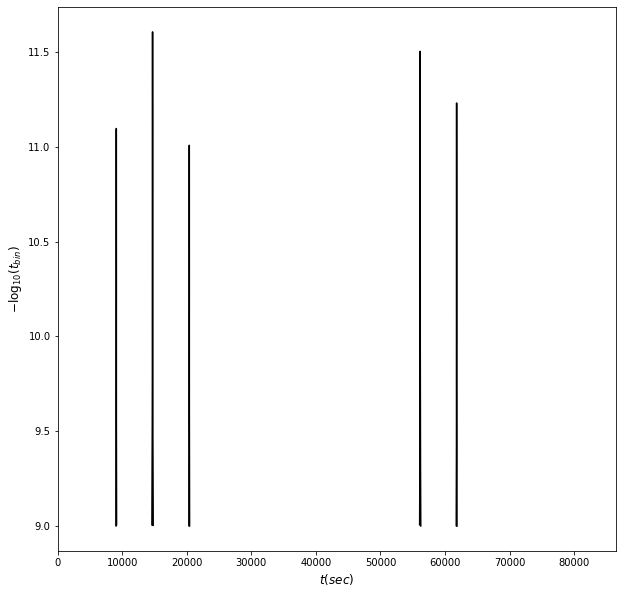

In [52]:
#3-4
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0

    if angles3[i]>1e-10 and pc_up3[i]>N_c:
        
        max_count = 0
        
        for j in range(tau):
            if angles4[i+j]>1e-10 and pc_up4[i+j]>N_c:
                
                if min(pc_up3[i], pc_up4[i+j])>max_count:
                    max_count = min(pc_up3[i], pc_up4[i+j])
                    t_success = np.append(t_success, i)
                    flag = 1
            else:
                if angles4[i-j]>1e-10 and pc_up4[i-j]>N_c:
                    if min(pc_up3[i], pc_up4[i-j])>max_count:
                        max_count = min(pc_up3[i], pc_up4[i-j])
                        t_success = np.append(t_success, i)
                        flag = 1
    if flag==0:
        c_success = np.append(c_success, 0)
    else:
        c_success = np.append(c_success, max_count)
    
'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=15)
ax.set_ylabel(r'$-\log_{10}(t_{bin})$', fontsize=15)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], -np.log10(dt*N_c/c_success), color = 'black') 

plt.savefig("precision_LA_SEA_300s.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1)

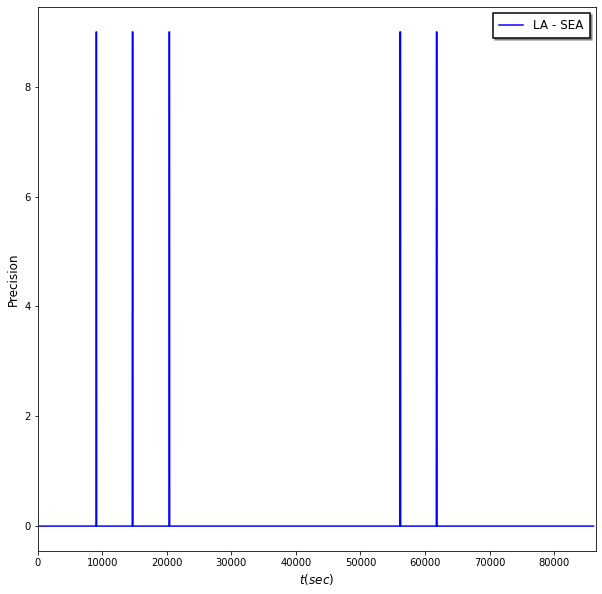

In [7]:
#1-2
c_success = np.array([])
t_success = np.array([])

N_c = 10
tau = 300


for i in range(tau+1,bigsteps-(tau+1)):
    flag = 0
    c_temp = 0
    if angles3[i]>1e-10 and pc_up3[i]>N_c:
        for j in range(tau):
            
            if (angles4[i+j]>1e-10 and pc_up4[i+j]>N_c):
                flag = 1
                if min(pc_up3[i], pc_up4[i+j], N_c)>c_temp:
                    c_temp = min(pc_up3[i], pc_up4[i+j], N_c)
                    
            if (angles4[i-j]>1e-10 and pc_up4[i-j]>N_c):
                flag = 1
                if min(pc_up3[i], pc_up4[i-j], N_c)>c_temp:
                    c_temp = min(pc_up3[i], pc_up4[i-j], N_c)
                    

    c_success = np.append(c_success, c_temp)
    if flag == 1:
        t_success = np.append(t_success,i)
    
pr = np.array([0]*np.size(c_success))   
for i in range (np.size(c_success)):
    if c_success[i] == 0:
        pr[i] = 0
    else:
        pr[i] = -np.log10(dt*N_c/c_success[i])
        

'plot formatting'
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim(0,bigsteps)
ax.set_xlim(0,bigsteps)
ax.set_xlabel(r'$t (sec)$', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)

ax.plot([i for i in range(tau+1,bigsteps-(tau+1))], pr, color = 'b') 
#legend format
leg = ax.legend((('LA - SEA', )), fontsize=12, framealpha=1, facecolor='white', edgecolor='k', fancybox=False, borderpad=0.5, shadow=True, loc='upper right')
bbox_to_anchor = (0.665, 0.55) #legend position
leg.get_frame().set_linewidth(1.5)

plt.savefig("precision_LA_SEA_5min.pdf" , dpi=600, facecolor='w', edgecolor='w',
        orientation='landscape', format='pdf',
        transparent=False, bbox_inches='tight', pad_inches=0.1) 

In [ ]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9

#two ground stations
#gs1_0 = generate_point(R, (10)*np.pi/180, 1*np.pi/180) # NY 40.7128° N, 74.0060° W
gs1_0 = generate_point(R, (90-40.7128)*np.pi/180, 74.0060*np.pi/180) # NY 40.7128° N, 74.0060° W
gs2_0 = generate_point(R, (90-33.7490)*np.pi/180, 84.3880*np.pi/180) # ATL 33.7490° N, 84.3880° W
gs3_0 = generate_point(R, (90-34.0522)*np.pi/180, 118.2437*np.pi/180) # LA 34.0522° N, 118.2437° W
gs4_0 = generate_point(R, (90-47.6062)*np.pi/180, 122.3321*np.pi/180) # SEA 47.6062° N, 122.3321° W

axis_earth = np.array([0,0,1]) #z-axis

#satellite
sat_0 = generate_point(R+h, 90*np.pi/180, 0*np.pi/180)
theta = 90;
axis_sat = np.array([0, math.sin(theta*np.pi/180), math.cos(theta*np.pi/180)]) # tilted axis in y-z plane

T_big = 86400
dT = 1
bigsteps = math.floor(T_big/dT)

# pc_up1 = np.array([]); pc_up2 = np.array([]); pc_up3 = np.array([]); pc_up4 = np.array([])
# angles1 = np.array([]); angles2 = np.array([]); angles3 = np.array([]); angles4 = np.array([]);
# distances1 = np.array([]); distances2 = np.array([]); distances3 = np.array([]); distances4 = np.array([]);

def sat_dynamics(t):
    
    #for t_gb in range(bigsteps):
    t_gb = t

    if t_gb%10000 == 0:
        print(t_gb)

    gs1 = evolve_vector(gs1_0, axis_earth, Om, t_gb*dT)
    gs2 = evolve_vector(gs2_0, axis_earth, Om, t_gb*dT)
    gs3 = evolve_vector(gs3_0, axis_earth, Om, t_gb*dT)
    gs4 = evolve_vector(gs4_0, axis_earth, Om, t_gb*dT)

    sat = evolve_vector(sat_0, axis_sat, om, t_gb*dT)

    angs =[np.dot(np.subtract(sat,gs1),gs1)/np.linalg.norm(gs1)/np.linalg.norm(np.subtract(sat,gs1)), 
        np.dot(np.subtract(sat,gs2),gs2)/np.linalg.norm(gs2)/np.linalg.norm(np.subtract(sat,gs2)),
              np.dot(np.subtract(sat,gs3),gs3)/np.linalg.norm(gs3)/np.linalg.norm(np.subtract(sat,gs3)),
            np.dot(np.subtract(sat,gs4),gs4)/np.linalg.norm(gs4)/np.linalg.norm(np.subtract(sat,gs4))]

    dists = [dst(gs1, sat), dst(gs2, sat), dst(gs3, sat), dst(gs4, sat)]


    eff_gs1_sat = eta(dists[0], h, 0.6, 0.1, 0.25)
    eff_gs2_sat = eta(dists[1], h, 0.6, 0.1, 0.25)
    eff_gs3_sat = eta(dists[2], h, 0.6, 0.1, 0.25)
    eff_gs4_sat = eta(dists[3], h, 0.6, 0.1, 0.25)

    #gs velocities
    v_gs1 = np.cross(gs1, Om*axis_earth)
    v_gs2 = np.cross(gs2, Om*axis_earth)
    v_gs3 = np.cross(gs3, Om*axis_earth)
    v_gs4 = np.cross(gs4, Om*axis_earth)

    #satellite velocity
    v_sat = np.cross(sat, om*axis_sat)

    #radial relative velocities
    v_rel_radial1 = np.dot(np.subtract(v_sat, v_gs1), np.subtract(sat, gs1)/np.linalg.norm(np.subtract(sat, gs1)))
    v_rel_radial2 = np.dot(np.subtract(v_sat, v_gs2), np.subtract(sat, gs2)/np.linalg.norm(np.subtract(sat, gs2)))
    v_rel_radial3 = np.dot(np.subtract(v_sat, v_gs3), np.subtract(sat, gs3)/np.linalg.norm(np.subtract(sat, gs3)))
    v_rel_radial4 = np.dot(np.subtract(v_sat, v_gs4), np.subtract(sat, gs4)/np.linalg.norm(np.subtract(sat, gs4)))

    #t_shift = t_bin/v_rel

    T1 = dt/abs(v_rel_radial1/c)
    T2 = dt/abs(v_rel_radial2/c)
    T3 = dt/abs(v_rel_radial3/c)
    T4 = dt/abs(v_rel_radial4/c)

    K1 = abs(v_rel_radial1/c)#1/abs(v_rel_radial1/c)
    eta_up1 = eff_gs1_sat
    
    pc_ups = [(eff_gs1_sat*pair_rate*T1), (eff_gs2_sat*pair_rate*T2), (eff_gs3_sat*pair_rate*T3),
               (eff_gs4_sat*pair_rate*T4)]
        
    return(pc_ups[0],pc_ups[1],pc_ups[2],pc_ups[3], angs[0], angs[1], angs[2], angs[3], K1, eta_up1, dists[0])

def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal
    angles 'phi'(in degrees) and polar angles 'theta'(in degrees) stored in lists of length
    n each.  There are num_sats equally-spaced satellites in each ring.  R is
    the radius of the earth (in meters), and h is the altitude of the
    satellites (in meters)
    Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  phi:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  theta:
      list of angles (in degrees) through which the polar rings are rotated about the x-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0
        
        for k in range(0, num_sats):
            count1 += 1
            S[i][count1] = generate_point(R + h, 2 * k * np.pi / num_sats + offset[i], np.pi/2-phi[i])
            rot_pt = generate_rotation([1, 0, 0], np.pi/2-theta[i]) * np.matrix(S[i][count1]).H
            S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [np.sin(theta[i]) * np.cos(phi[i]), np.sin(theta[i]) * np.sin(phi[i]), np.cos(theta[i])]

    return S

t_start = time.time()
data = Parallel(n_jobs=15)(delayed(sat_dynamics)(t) for t in range(bigsteps))
print(time.time() - t_start)


print("game over")        
with open('data_4cities_2orbits_tilted50.npy', 'wb') as f:
    np.save(f, data) 

